In [7]:
import onnxruntime as rt
import uproot
import numpy as np
from matplotlib import pyplot as plt
from collections import OrderedDict
from coffea.util import load
import awkward as ak
from sklearn.preprocessing import normalize

seq_inputs = OrderedDict({
            "jet_log_pt": ["JetGoodFromHiggsOrdered5Jets_pt", "log_norm"],
            "jet_eta": ["JetGoodFromHiggsOrdered5Jets_eta", "norm"],
            "jet_phi": ["JetGoodFromHiggsOrdered5Jets_phi", "norm"],
            "jet_log_mass": ["JetGoodFromHiggsOrdered5Jets_mass", "log_norm"],
            })
glob_inputs = OrderedDict({
            # "Arctanh_Delta_pairing_probabilities": ["events", "Arctanh_Delta_pairing_probabilities"],
            "maxDeltaR_Higgjj": ["events", "dR_max", "norm"],
            "minDeltaR_Higgjj": ["events", "dR_min", "norm"],
            "HT": ["events", "HT", "log_norm"],
            "higgs1_reco_pt": ["HiggsLeading", "pt", "log_norm"],
            "higgs1_reco_eta": ["HiggsLeading", "eta", "norm"],
            "higgs1_reco_phi": ["HiggsLeading", "phi", "norm"],
            "higgs1_reco_mass": ["HiggsLeading", "mass", "log_norm"],
            "higgs1_reco_dR": ["HiggsLeading", "dR", "norm"],
            "higgs1_helicityCosTheta": ["HiggsLeading", "helicityCosTheta", "norm"],
            "higgs2_reco_pt": ["HiggsSubLeading", "pt", "log_norm"],
            "higgs2_reco_eta": ["HiggsSubLeading", "eta", "norm"],
            "higgs2_reco_phi": ["HiggsSubLeading", "phi", "norm"],
            "higgs2_reco_mass": ["HiggsSubLeading", "mass", "log_norm"],
            "higgs2_reco_dR": ["HiggsSubLeading", "dR", "norm"],
            "higgs2_helicityCosTheta": ["HiggsSubLeading", "helicityCosTheta", "norm"],
            "hh_vec_pt": ["HH", "pt", "log_norm"],
            "hh_vec_eta": ["HH", "eta", "norm"],
            "hh_vec_phi": ["HH", "phi", "norm"],
            "hh_vec_mass": ["HH", "mass", "log_norm"],
            "hh_vec_DeltaR": ["HH", "dR", "norm"],
            "hh_vec_DeltaEta": ["HH", "dEta", "norm"],
            "hh_vec_DeltaPhi": ["HH", "dPhi", "norm"],
            }
)
seq_inputs_AN23_184 = OrderedDict({
            "jet_eta": ["JetGoodFromHiggsOrdered5Jets_eta", "norm"],
            "jet_log_mass": ["JetGoodFromHiggsOrdered5Jets_mass", "log_norm"],
            "jet_phi": ["JetGoodFromHiggsOrdered5Jets_phi", "norm"],
            "jet_log_pt": ["JetGoodFromHiggsOrdered5Jets_pt", "log_norm"],
            })
glob_inputs_AN23_184 = OrderedDict({
            "HT": ["events", "HT", "log_norm"],
            "maxDeltaR_Higgjj": ["events", "dR_max", "norm"],
            "minDeltaR_Higgjj": ["events", "dR_min", "norm"],
            "sigma_over_higgs1_reco_mass": ["events", "sigma_over_higgs1_reco_mass", "norm"],
            "sigma_over_higgs2_reco_mass": ["events", "sigma_over_higgs2_reco_mass", "norm"],
            "higgs1_DeltaEtajj": ["HiggsLeading", "dEta", "norm"],
            "higgs1_DeltaPhijj": ["HiggsLeading", "dPhi", "norm"],
            # "higgs1_reco_dR": ["HiggsLeading", "dR", "norm"],
            "higgs1_reco_eta": ["HiggsLeading", "eta", "norm"],
            "higgs1_helicityCosTheta": ["HiggsLeading", "helicityCosTheta", "norm"],
            "higgs1_reco_phi": ["HiggsLeading", "phi", "norm"],
            "higgs1_reco_mass": ["HiggsLeading", "mass", "log_norm"],
            "higgs1_reco_pt": ["HiggsLeading", "pt", "log_norm"],
            "higgs2_DeltaEtajj": ["HiggsSubLeading", "dEta", "norm"],
            "higgs2_DeltaPhijj": ["HiggsSubLeading", "dPhi", "norm"],
            # "higgs2_reco_dR": ["HiggsSubLeading", "dR", "norm"],
            "higgs2_reco_eta": ["HiggsSubLeading", "eta", "norm"],
            "higgs2_helicityCosTheta": ["HiggsSubLeading", "helicityCosTheta", "norm"],
            "higgs2_reco_phi": ["HiggsSubLeading", "phi", "norm"],
            "higgs2_reco_mass": ["HiggsSubLeading", "mass", "log_norm"],
            "higgs2_reco_pt": ["HiggsSubLeading", "pt", "log_norm"],
            "hh_CosThetaStar_CS": ["HH", "Costhetastar_CS", "norm"],
            "hh_vec_DeltaEta": ["HH", "dEta", "norm"],
            "hh_vec_DeltaPhi": ["HH", "dPhi", "norm"],
            "hh_vec_DeltaR": ["HH", "dR", "norm"],
            "hh_vec_eta": ["HH", "eta", "norm"],
            "hh_vec_mass": ["HH", "mass", "log_norm"],
            "hh_vec_phi": ["HH", "phi", "norm"],
            "hh_vec_pt": ["HH", "pt", "log_norm"],
            "add_jet1pt_Higgs1_deta": ["add_jet1pt", "LeadingHiggs_dEta", "norm"],
            "add_jet1pt_Higgs1_dphi": ["add_jet1pt", "LeadingHiggs_dPhi", "norm"],
            "add_jet1pt_Higgs1_m": ["add_jet1pt", "LeadingHiggs_mass", "norm"],
            "add_jet1pt_Higgs2_deta": ["add_jet1pt", "SubLeadingHiggs_dEta", "norm"],
            "add_jet1pt_Higgs2_dphi": ["add_jet1pt", "SubLeadingHiggs_dPhi", "norm"],
            "add_jet1pt_Higgs2_m": ["add_jet1pt", "SubLeadingHiggs_mass", "norm"],
            "add_jet1pt_eta": ["add_jet1pt", "eta", "norm"],
            "add_jet1pt_mass": ["add_jet1pt", "mass", "norm"],
            "add_jet1pt_phi": ["add_jet1pt", "phi", "norm"],
            "add_jet1pt_pt": ["add_jet1pt", "pt", "norm"],
            }
)

In [8]:
base_path = "/work/tharte/datasets/onnx_spanet_models_for_classification_sig_bkg/"
model_path =f'{base_path}1_15_8_spanet_classifier_fromKevin_classification_5jetinput_initial_inputset.onnx'
# model_path ='/work/tharte/datasets/onnx_spanet_models_for_classification_sig_bkg/1_15_1_from_1_14_5b_spanet_hh4b_classifier_test_signal_accuracy_metric_jet_ptetaphimass_glob_dr_ht_higgsleadsublead_HH.onnx'
# model_path = '/work/tharte/datasets/onnx_spanet_models_for_classification_sig_bkg/1_15_8_spanet_hh4b_classification_trial_version2_testing_model_not_working_during_saturdayshift.onnx'
model_path = f'{base_path}1_15_8_spanet_hh4b_classification_trial_version3_testing_model_not_working_during_saturdayshift_particle_balance_add_layer.onnx'
model_path = f'{base_path}1_15_8_spanet_hh4b_classification_trial_version4_testing_model_not_working_during_saturdayshift_no_weight_balance.onnx'
model_path = f'{base_path}1_15_8_spanet_hh4b_classification_trial_version5_testing_model_not_working_during_saturdayshift_clamp_negative_weights.onnx'
model_path = f'{base_path}1_15_8_spanet_hh4b_classification_trial_version6_testing_model_not_working_sundayshift_5times_1_weight.onnx'
model_path = f'{base_path}1_15_8_spanet_hh4b_classification_trial_version7_testing_model_not_working_sundayshift_6times_1_weight.onnx'
model_path = f'{base_path}1_15_8_spanet_hh4b_classification_trial_version7_testing_model_not_working_sundayshift_6times_1_weight_full_training.onnx'
#model_path = f'{base_path}spanet_hh4b_classification_trial_version8_testing_model_not_working_sundayshift_different_layer_configuration.onnx'
model_path = f'{base_path}1_15_8_spanet_hh4b_classification_trial_version9_testing_model_not_working_sundayshift_manually_equalising_weight_full_training.onnx'
model_path = f'{base_path}kevin_model_hh4b_classification_5jetinput_AN23_183_variables.onnx'
session = rt.InferenceSession(
    model_path,
    providers=rt.get_available_providers()
)
# print the input/putput name and shape
input_name=[input.name for input in session.get_inputs()]
output_name=[output.name for output in session.get_outputs()]
print("Inputs name:", input_name)
print("Outputs name:", output_name)

# input_example = {input_name[0]: input_data}

# output1 = session_combine1.run(output_name, input_example)[0]


Inputs name: ['Jet_data', 'Jet_mask', 'Event_data', 'Event_mask', 'HiggsLeading_data', 'HiggsLeading_mask', 'HiggsSubLeading_data', 'HiggsSubLeading_mask', 'HH_data', 'HH_mask', 'add_jet1pt_data', 'add_jet1pt_mask']
Outputs name: ['h1_assignment_probability', 'h2_assignment_probability', 'h1_detection_probability', 'h2_detection_probability', 'EVENT/class']


In [185]:
coffea_file = "/work/tharte/datasets/sig_bkg_classifier/1_14_5c_spanet_ptflat_Update_newLeptonVeto_3L1Cut_UpdateJetVetoMap_save_sig_bkg_parameters/output_all.coffea"
columns = load(coffea_file)["columns"]
print(columns.keys())

dict_keys(['DATA_JetMET_JMENano_E_skimmed', 'DATA_JetMET_JMENano_F_skimmed', 'DATA_JetMET_JMENano_G_skimmed', 'GluGlutoHHto4B_spanet_kl-0p00_kt-0p00_c2-0p00_skimmed', 'GluGlutoHHto4B_spanet_kl-0p50_kt-1p00_c2-0p00_skimmed', 'GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_skimmed', 'GluGlutoHHto4B_spanet_kl-1p50_kt-1p00_c2-0p00_skimmed', 'GluGlutoHHto4B_spanet_kl-2p00_kt-1p00_c2-0p00_skimmed', 'GluGlutoHHto4B_spanet_kl-2p45_kt-1p00_c2-0p00_skimmed', 'GluGlutoHHto4B_spanet_kl-3p00_kt-1p00_c2-0p00_skimmed', 'GluGlutoHHto4B_spanet_kl-3p50_kt-1p00_c2-0p00_skimmed', 'GluGlutoHHto4B_spanet_kl-4p00_kt-1p00_c2-0p00_skimmed', 'GluGlutoHHto4B_spanet_kl-5p00_kt-1p00_c2-0p00_skimmed', 'GluGlutoHHto4B_spanet_kl-m1p00_kt-1p00_c2-0p00_skimmed', 'GluGlutoHHto4B_spanet_kl-m2p00_kt-1p00_c2-0p00_skimmed'])


In [186]:
# colSigSM = columns["GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_skimmed"]['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE']['4b_signal_region']['nominal']
colSigSM = columns["GluGlutoHHto4B_spanet_kl-2p45_kt-1p00_c2-0p00_skimmed"]['GluGlutoHHto4B_spanet_kl-2p45_kt-1p00_c2-0p00_2022_postEE']['4b_signal_region']['nominal']
colBgDATA = columns["DATA_JetMET_JMENano_E_skimmed"]["DATA_JetMET_JMENano_E_2022_postEE_EraE"]["2b_signal_region_postW"]['nominal']
# colSigSM = columns["GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_skimmed"]['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE']['4b_signal_region']['nominal']
# colBgDATA = columns["DATA_JetMET_JMENano_E_skimmed"]["DATA_JetMET_JMENano_E_2022_postEE_EraE"]["4b_signal_region"]['nominal']

In [187]:
def get_input_name(collection, input_name):
    for name in input_name:
        # in case of "events", the last s has to be removed to map to "Event_data"
        if collection == "events":
            collection = "event"
        if collection.lower() in name.lower():
            data_name = f"{'_'.join(name.split('_')[:-1])}_data"
            mask_name = f"{'_'.join(name.split('_')[:-1])}_mask"
            return data_name, mask_name
    raise ValueError(f"No {collection} found in {input_name}")


def extract_inputs_global(input_name, events, variables):
    """Extract inputs for SPANet global inputs."""
    variables_dict = {}
    for attributes in variables:
        collection = attributes[0]
        feature = attributes[1]
        scale = attributes[2]
        data_name, mask_name = get_input_name(collection, input_name)
        if data_name not in variables_dict.keys():
            variables_dict[data_name] = []

        ak_array = ak.where(events[f"{collection}_{feature}"].value!=-999.0, events[f"{collection}_{feature}"].value, PAD_VALUE_SPANET)
        arr = np.array(
            ak.to_numpy(ak_array, allow_missing=True),
            dtype=np.float32,
        )
        if scale and "log" in scale:
            arr = np.log(arr+1)
        
            
        if arr.ndim == 1:
            arr = arr[:, None]

        variables_dict[data_name].append(arr)
        if mask_name not in variables_dict.keys():
            mask_ak = ak.ones_like(ak_array)
            mask_np = ak.to_numpy(mask_ak, allow_missing=True)
            mask_np = np.array(np.where(ak_array!=9999,ak_array,ak.to_numpy(ak.zeros_like(ak_array))))
            if mask_np.ndim == 1:
                mask_np = mask_np[:, None]
            variables_dict[mask_name] = mask_np.astype(np.bool_)
    for key, value in variables_dict.items():
        if "data" in key:
            variables_dict[key] = np.stack(value, axis=-1)
    return variables_dict


In [188]:
PAD_VALUE_SPANET = 9999
def define_spanet_sequential_inputs(
    events, max_num_jets_spanet, spanet_input_name_list, counts
):
    """
    Define the sequential (2D arrays) input features for the SPANet model.
    """
    input_dict = {}

    for variable_name, scale in spanet_input_name_list:
        input_vals = np.array(
            ak.to_numpy(
                ak.fill_none(
                    ak.pad_none(
                        ak.unflatten(events[variable_name].value,counts),
                        max_num_jets_spanet,
                        clip=True,
                    ),
                    value=PAD_VALUE_SPANET,
                ),
                allow_missing=True,
            ),
            dtype=np.float32,
        )
        input_vals = np.where(input_vals!=-999.0, input_vals, PAD_VALUE_SPANET)
        if "log" in scale:
            input_vals = np.log(input_vals+1)
        input_dict[variable_name] = input_vals
    input_dict = np.stack(list(input_dict.values()), axis=-1)
    mask = np.array(
        ak.to_numpy(
            ak.fill_none(
                ak.pad_none(
                    ak.ones_like(ak.unflatten(events[variable_name].value,counts)),
                    max_num_jets_spanet,
                    clip=True,
                ),
                value=0,
            ),
            allow_missing=True,
        ),
        dtype=np.bool_,
    )
    inputs_complete = {input_name[0]: input_dict, input_name[1]: mask}

    return inputs_complete


In [189]:
seq_input_vals =  define_spanet_sequential_inputs(colSigSM, 5, seq_inputs_AN23_184.values(), colSigSM["JetGoodFromHiggsOrdered5Jets_N"].value)
print(colBgDATA.keys())
seq_input_vals_data =  define_spanet_sequential_inputs(colBgDATA, 5, seq_inputs_AN23_184.values(), colBgDATA["JetGoodFromHiggsOrdered5Jets_N"].value)
print(seq_input_vals)

dict_keys(['weight', 'events_Delta_pairing_probabilities', 'events_dR_min', 'events_sigma_over_higgs1_reco_mass', 'events_dR_max', 'events_Arctanh_Delta_pairing_probabilities', 'events_year', 'events_Padded_Arctanh_Delta_pairing_probabilities', 'events_sigma_over_higgs2_reco_mass', 'events_Binned_Arctanh_Delta_pairing_probabilities', 'events_HT', 'events_era', 'HH_dPhi', 'HH_phi', 'HH_dR', 'HH_eta', 'HH_dEta', 'HH_Costhetastar_CS', 'HH_pt', 'HH_mass', 'HiggsLeading_helicityCosTheta', 'HiggsLeading_dPhi', 'HiggsLeading_phi', 'HiggsLeading_dR', 'HiggsLeading_eta', 'HiggsLeading_dEta', 'HiggsLeading_pt', 'HiggsLeading_mass', 'HiggsSubLeading_helicityCosTheta', 'HiggsSubLeading_dPhi', 'HiggsSubLeading_phi', 'HiggsSubLeading_dR', 'HiggsSubLeading_eta', 'HiggsSubLeading_dEta', 'HiggsSubLeading_pt', 'HiggsSubLeading_mass', 'JetGoodFromHiggsOrdered_N', 'JetGoodFromHiggsOrdered_phi', 'JetGoodFromHiggsOrdered_eta', 'JetGoodFromHiggsOrdered_pt', 'JetGoodFromHiggsOrdered_mass', 'JetGoodFromHiggsOr

In [190]:
glob_input_vals = extract_inputs_global(input_name[2:], colSigSM, glob_inputs_AN23_184.values())
glob_input_vals_data = extract_inputs_global(input_name[2:], colBgDATA, glob_inputs_AN23_184.values())

In [191]:
print(len(colSigSM["JetGoodFromHiggsOrdered5Jets_pt"].value))
print(len(colSigSM["weight"].value))
print(len(ak.unflatten(colSigSM["JetGoodFromHiggsOrdered5Jets_pt"].value,colSigSM["JetGoodFromHiggsOrdered5Jets_N"].value)))

367199
78861
78861


In [192]:
full_inputs = seq_input_vals | glob_input_vals
full_inputs_data = seq_input_vals_data | glob_input_vals_data
inputs_red = {k: v[:1000] for k, v in full_inputs.items()}
inputs_red_data = {k: v[:1000] for k, v in full_inputs_data.items()}
#for key, val in inputs_red.items():
#    print(f"{key}: {val}")

In [193]:
outputs = session.run(output_name, inputs_red)
outputs_data = session.run(output_name, inputs_red_data)

In [194]:
print(outputs[4][:1])
print(outputs_data[4][:1])

[[0.11702362 0.8829764 ]]
[[0.9539411  0.04605887]]


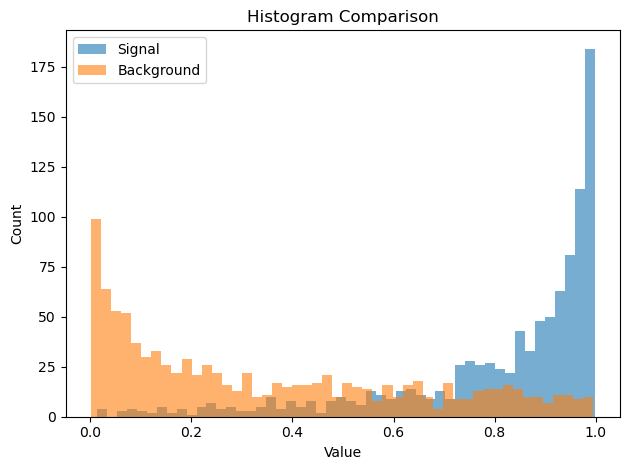

In [195]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.hist(outputs[4][:,1], bins=50, alpha=0.6, label="Signal")
ax.hist(outputs_data[4][:,1], bins=50, alpha=0.6, label="Background")

ax.set_xlabel("Value")
ax.set_ylabel("Count")
ax.set_title("Histogram Comparison")
ax.legend()

plt.tight_layout()
plt.show()

In [196]:
for key, val in inputs_red.items():
    print(f"{key}: shape={val.shape}, dtype={val.dtype}, "
          f"min={val.min():.3f}, max={val.max():.3f}")

Jet_data: shape=(1000, 5, 4), dtype=float32, min=-3.142, max=9999.000
Jet_mask: shape=(1000, 5), dtype=bool, min=0.000, max=1.000
Event_data: shape=(1000, 1, 5), dtype=float32, min=0.040, max=7.496
Event_mask: shape=(1000, 1), dtype=bool, min=1.000, max=1.000
HiggsLeading_data: shape=(1000, 1, 7), dtype=float32, min=-3.139, max=6.497
HiggsLeading_mask: shape=(1000, 1), dtype=bool, min=1.000, max=1.000
HiggsSubLeading_data: shape=(1000, 1, 7), dtype=float32, min=-3.327, max=6.388
HiggsSubLeading_mask: shape=(1000, 1), dtype=bool, min=1.000, max=1.000
HH_data: shape=(1000, 1, 8), dtype=float32, min=-6.232, max=7.294
HH_mask: shape=(1000, 1), dtype=bool, min=1.000, max=1.000
add_jet1pt_data: shape=(1000, 1, 10), dtype=float32, min=-3.142, max=9999.000
add_jet1pt_mask: shape=(1000, 1), dtype=bool, min=0.000, max=1.000


In [197]:
print("=== INPUTS ===")
for inp in session.get_inputs():
    print(f"  Name:  {inp.name},  Shape: {inp.shape},  Type:  {inp.type}")

print("=== OUTPUTS ===")
for out in session.get_outputs():
    print(f"  Name:  {out.name},  Shape: {out.shape},  Type:  {out.type}")

=== INPUTS ===
  Name:  Jet_data,  Shape: ['batch_size', 'num_Jet', 4],  Type:  tensor(float)
  Name:  Jet_mask,  Shape: ['batch_size', 'num_Jet'],  Type:  tensor(bool)
  Name:  Event_data,  Shape: ['batch_size', 'num_Event', 5],  Type:  tensor(float)
  Name:  Event_mask,  Shape: ['batch_size', 'num_Event'],  Type:  tensor(bool)
  Name:  HiggsLeading_data,  Shape: ['batch_size', 'num_HiggsLeading', 7],  Type:  tensor(float)
  Name:  HiggsLeading_mask,  Shape: ['batch_size', 'num_HiggsLeading'],  Type:  tensor(bool)
  Name:  HiggsSubLeading_data,  Shape: ['batch_size', 'num_HiggsSubLeading', 7],  Type:  tensor(float)
  Name:  HiggsSubLeading_mask,  Shape: ['batch_size', 'num_HiggsSubLeading'],  Type:  tensor(bool)
  Name:  HH_data,  Shape: ['batch_size', 'num_HH', 8],  Type:  tensor(float)
  Name:  HH_mask,  Shape: ['batch_size', 'num_HH'],  Type:  tensor(bool)
  Name:  add_jet1pt_data,  Shape: ['batch_size', 'num_add_jet1pt', 10],  Type:  tensor(float)
  Name:  add_jet1pt_mask,  Shape:

In [261]:
index = ak.where(ak.to_numpy(colSigSM["events_event"].value) ==6987588)
index
# index = colSigSM["events_event"].value[111]
# print(index)
# outputs[4][:,1][101]

import h5py
with h5py.File("/work/tharte/datasets/sig_bkg_classifier/1_15_8_spanet_ptflat_Update_newLeptonVeto_3L1Cut_UpdateJetVetoMap_5jet_collection_spanet_classifier_kevin_AN23_184_vars/hh4b_classification_5jetinput_AN23_183_variables.h5", "r") as f:
    def describe(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"{name}: shape={obj.shape}, dtype={obj.dtype}")
        else:
            print(f"{name}/")

    # f.visititems(describe)
    print(f["INPUTS/Event/event"][()])
    events_h5 = f["INPUTS/Event/event"][()]
    counter =0
    print(f["INPUTS/Event/kl"][()])
    print(sum(f["INPUTS/Event/kl"][()]==2.45))
    print(len(f["INPUTS/Event/kl"][()]==2.45))
    print(len(colSigSM["events_event"].value))

    coffea_arr = colSigSM["HH_pt"].value
    coffea_event = colSigSM["events_event"].value
    h5_arr = f["INPUTS/HH/pt"][()]# [f["INPUTS/Event/kl"][()]==2.45]
    h5_event = f["INPUTS/Event/event"][()]# [f["INPUTS/Event/kl"][()]==2.45]
    kl_arr = f["INPUTS/Event/kl"][()]# [f["INPUTS/Event/kl"][()]==2.45]
    score_arr = f["CLASSIFICATIONS/EVENT/class"][()]# [f["INPUTS/Event/kl"][()]==2.45]

    tol = 1e-15
    # mask = np.isclose(h5_arr, coffea_arr, atol=tol) & (kl_arr == 2.45)
    # print(np.isclose(h5_arr, coffea_arr, atol=tol))
    # print(len(np.isclose(h5_arr, coffea_arr, atol=tol)))
    # print(sum(np.isclose(h5_arr, coffea_arr, atol=tol)))
    # print(sum(np.isclose(h5_arr, coffea_arr, atol=tol)))
    
    # print(mask)
    match_indices = np.where(mask)[0]
    # print(match_indices)
# 
    for idx, h5_val in enumerate(h5_arr[:100]):
        if np.isclose(float(kl_arr[idx]), 2.45, atol=tol):
            # Find indices in coffea_arr that are close to h5_val
            close_indices = np.where(np.isclose(coffea_arr, h5_val, atol=tol))[0]
            if len(close_indices) > 0:
                # Take the first close index (or loop through all if needed)
                coffea_idx = close_indices[0]
                inputs_red = {k: np.expand_dims(v[coffea_idx],0) for k, v in full_inputs.items()}
                outputs = session.run(output_name, inputs_red)
                print(
                    f"Index H5: {idx}, coffea {coffea_idx} \n"
                    f"Event number H5 {h5_event[idx]}, coffea {coffea_event[coffea_idx]} \n"
                    f"HH_pT H5: {h5_arr[idx]}, coffea {coffea_arr[coffea_idx]}\n"
                    f"Score H5: {score_arr[idx]} coffea: {outputs[4][:1]}"
                )
                counts = colSigSM["JetGoodFromHiggsOrdered5Jets_N"].value
                coffea_jetpt = ak.unflatten(colSigSM['JetGoodFromHiggsOrdered5Jets_pt'].value,counts)
                # print(f"pT: H5: {f['INPUTS/Jet/pt'][()][f['INPUTS/Event/kl'][()]==2.45][idx]}, coffea {coffea_jetpt[coffea_idx]}")
                print(f"pT: H5: {f['INPUTS/Jet/pt'][()][idx]}, coffea {coffea_jetpt[coffea_idx]}")
                
    # for idx in match_indices[:10]:
    #     coffea_idx = np.where(coffea_arr == h5_arr[idx])[0][0]
    #     print(coffea_idx)
    #     inputs_red = {k: np.expand_dims(v[coffea_idx],0) for k, v in full_inputs.items()}
    #     outputs = session.run(output_name, inputs_red)
    #     print(
    #         f"Index in coffea_list: {np.where(coffea_arr == h5_arr[idx])[0][0]}, "
    #         f"Index in h5_list: {idx}, "
    #         f"Event number: {h5_arr[idx]}, {coffea_arr[np.where(coffea_arr == h5_arr[idx])[0][0]]}"
    #         f"Score: {score_arr[idx]}"
    #         f"PocketCoffea Score: {outputs[4][:1]}"
    #     )
    #     print("Comparing pt:")
    #     counts = colSigSM["JetGoodFromHiggsOrdered5Jets_N"].value
    #     coffea_jetpt = ak.unflatten(colSigSM['JetGoodFromHiggsOrdered5Jets_pt'].value,counts)
    #     print(f"PocketCoffea pT: {coffea_jetpt[np.where(coffea_arr == h5_arr[idx])[0][0]]} | H5 pT: {f['INPUTS/Jet/pt'][()][idx]}")
    #     print(f"PocketCoffea HH_mass: {colSigSM['HH_mass'].value[np.where(coffea_arr == h5_arr[idx])[0][0]]} | H5 mass: {f['INPUTS/HH/mass'][()][idx]}")
    
    # for idx, eventnum in enumerate(colSigSM["events_event"].value):
    #     if idx%1000 == 0:
    #         print(idx)
    #     if eventnum in events_h5 and f["INPUTS/Event/kl"][()][list(events_h5).index(eventnum)]==2.45: 
    #         print(idx)
    #         print(f"{eventnum} is at {list(events_h5).index(eventnum)}")
    #         print(f["CLASSIFICATIONS/EVENT/class"][()][list(events_h5).index(eventnum)])
    #         inputs_red = {k: np.expand_dims(v[idx],0) for k, v in full_inputs.items()}
    #         outputs = session.run(output_name, inputs_red)
    #         print(outputs[4][:,1])
    #         counter +=1
    #     if counter >=10:
    #         break

[7.2035994e+08 2.9865878e+08 7.3360934e+08 ... 2.1016817e+09 2.6524616e+08
 5.5263757e+08]
[9999. 9999. 9999. ... 9999. 9999. 9999.]
15773
511130
78861
Index H5: 41, coffea 66641 
Event number H5 914.0, coffea 914 
HH_pT H5: 103.85092163085938, coffea 103.85092210129989
Score H5: [0.2977813 0.7022187] coffea: [[0.29778245 0.7022176 ]]
pT: H5: [140.93887   87.582306 119.75516   50.32237   69.44854 ], coffea [141, 87.6, 120, 50.3, 69.4]
Index H5: 67, coffea 63646 
Event number H5 631.0, coffea 631 
HH_pT H5: 13.567046165466309, coffea 13.56704615671852
Score H5: [0.04051555 0.9594845 ] coffea: [[0.02746429 0.9725357 ]]
pT: H5: [ 109.83029    95.879     130.16922    59.033497 9999.      ], coffea [110, 95.9, 130, 59]
Index H5: 88, coffea 10333 
Event number H5 153.0, coffea 905 
HH_pT H5: 42.939701080322266, coffea 42.940049711253856
Score H5: [0.02096272 0.9790373 ] coffea: [[0.02045426 0.9795457 ]]
pT: H5: [ 143.00616  137.67033  181.60191   62.3221  9999.     ], coffea [242, 67.6, 177,

In [224]:
counts = colSigSM["JetGoodFromHiggsOrdered5Jets_N"].value
for features in seq_inputs.values():
    print(features[0])
    print(ak.unflatten(colSigSM[features[0]].value,counts)[index])
for features in glob_inputs.values():
    print(f"{features[0]}_{features[1]}")
    print(colSigSM[f"{features[0]}_{features[1]}"].value[index])

JetGoodFromHiggsOrdered5Jets_pt
[]
JetGoodFromHiggsOrdered5Jets_eta
[]
JetGoodFromHiggsOrdered5Jets_phi
[]
JetGoodFromHiggsOrdered5Jets_mass
[]
events_dR_max
[]
events_dR_min
[]
events_HT
[]
HiggsLeading_pt
[]
HiggsLeading_eta
[]
HiggsLeading_phi
[]
HiggsLeading_mass
[]
HiggsLeading_dR
[]
HiggsLeading_helicityCosTheta
[]
HiggsSubLeading_pt
[]
HiggsSubLeading_eta
[]
HiggsSubLeading_phi
[]
HiggsSubLeading_mass
[]
HiggsSubLeading_dR
[]
HiggsSubLeading_helicityCosTheta
[]
HH_pt
[]
HH_eta
[]
HH_phi
[]
HH_mass
[]
HH_dR
[]
HH_dEta
[]
HH_dPhi
[]


In [200]:
coffea_file = "/work/tharte/datasets/sig_bkg_classifier/1_15_8_spanet_ptflat_Update_newLeptonVeto_3L1Cut_UpdateJetVetoMap_5jet_collection_spanet_classifier_kevin/output_all.coffea"
genweights = load(coffea_file)["sum_genweights"]["GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE"]
print(genweights)

218969.87056643964


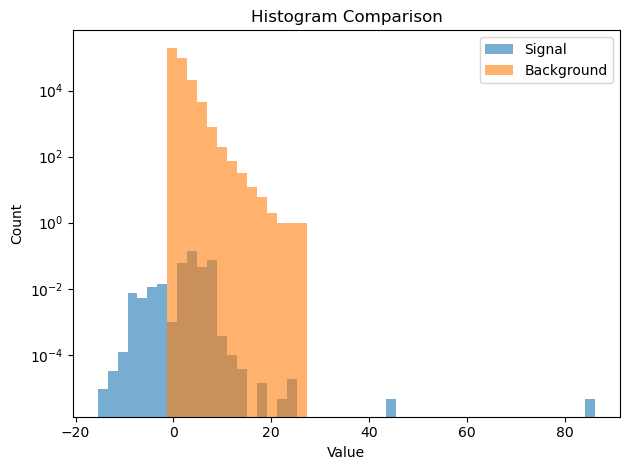

In [201]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.hist(colSigSM["weight"].value, bins=50, range=(min(colSigSM["weight"].value), max(colSigSM["weight"].value)), alpha=0.6, label="Signal", weights=ak.ones_like(colSigSM["weight"].value)*1/genweights)
ax.hist(colBgDATA["weight"].value, bins=50, range=(min(colSigSM["weight"].value), max(colSigSM["weight"].value)), alpha=0.6, label="Background")

ax.set_xlabel("Value")
ax.set_ylabel("Count")
ax.set_title("Histogram Comparison")
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()